### Tuning Pytorch2 Agent Hyperparameters
#### Test Configuration: MEDIUM
#### 10 States, Alphabet Size 2


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [28]:
results = pd.read_csv("pytorch_test_10_2.csv")
results.drop(columns='id',inplace=True)
results

,self.eps_decay_steps,self.lr,self.gamma,self.n_hist,sum_smooth_av
0,5000,0.001,0.990,3,5962.988571
1,4500,0.001,0.990,3,6420.017143
2,4000,0.001,0.990,3,5965.702857
3,3500,0.001,0.990,3,6043.525714
4,3000,0.001,0.990,3,6548.920000
...,...,...,...,...,...
61,500,0.001,0.825,12,3963.828571
62,500,0.001,0.800,6,4232.462857
63,500,0.001,0.800,12,4171.257143
64,500,0.001,0.775,6,3882.245714


### Handle Outliers:
1. Remove Outliers (Sum > 10,000)
2. Use Logarithmic Scale of Sum of Smoothed Average

In [29]:
outlier = []
for index, row in results.iterrows():
    if row['sum_smooth_av'] > 10000:
        outlier.append(math.nan)
    else:
        outlier.append(0)
results = pd.concat([results, pd.DataFrame(outlier,columns=['outlier'])], axis=1)

results.dropna(inplace=True)


,self.eps_decay_steps,self.lr,self.gamma,self.n_hist,sum_smooth_av,outlier
0,5000,0.001,0.990,3,5962.988571,0.0
1,4500,0.001,0.990,3,6420.017143,0.0
2,4000,0.001,0.990,3,5965.702857,0.0
3,3500,0.001,0.990,3,6043.525714,0.0
4,3000,0.001,0.990,3,6548.920000,0.0
...,...,...,...,...,...,...
61,500,0.001,0.825,12,3963.828571,0.0
62,500,0.001,0.800,6,4232.462857,0.0
63,500,0.001,0.800,12,4171.257143,0.0
64,500,0.001,0.775,6,3882.245714,0.0


In [30]:
results['log_sum'] = np.log(results['sum_smooth_av'])
results

,self.eps_decay_steps,self.lr,self.gamma,self.n_hist,sum_smooth_av,outlier,log_sum
0,5000,0.001,0.990,3,5962.988571,0.0,8.693327
1,4500,0.001,0.990,3,6420.017143,0.0,8.767176
2,4000,0.001,0.990,3,5965.702857,0.0,8.693782
3,3500,0.001,0.990,3,6043.525714,0.0,8.706743
4,3000,0.001,0.990,3,6548.920000,0.0,8.787055
...,...,...,...,...,...,...,...
61,500,0.001,0.825,12,3963.828571,0.0,8.284966
62,500,0.001,0.800,6,4232.462857,0.0,8.350539
63,500,0.001,0.800,12,4171.257143,0.0,8.335973
64,500,0.001,0.775,6,3882.245714,0.0,8.264169


### Plot Sum of Smoothed Averages Against self.eps_decay_steps, self.gamma

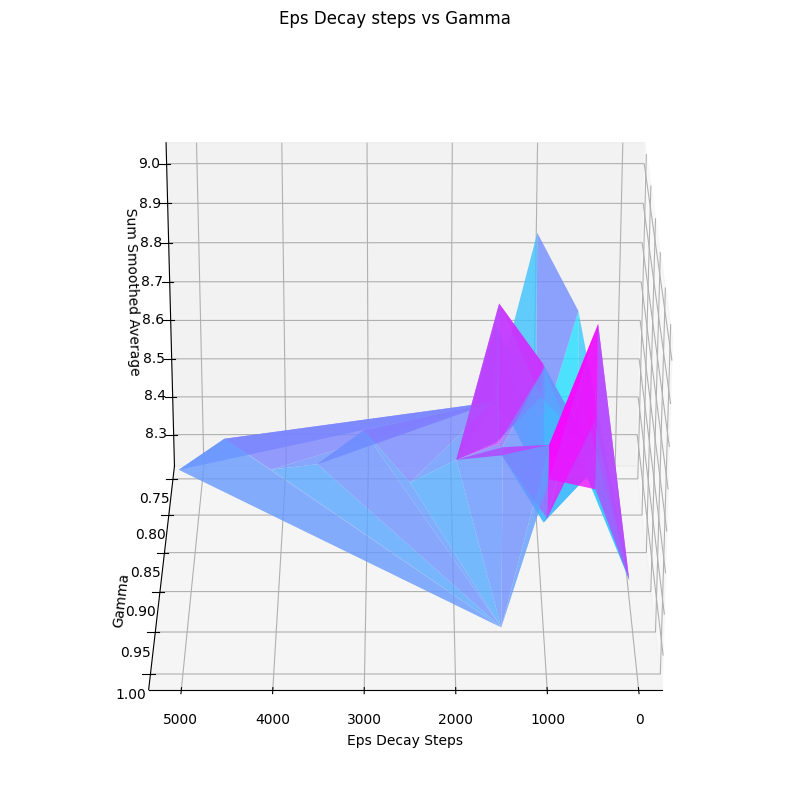

In [42]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(25, 90)

ax.plot_trisurf(results['self.eps_decay_steps'], results['self.gamma'], results['log_sum'], cmap='cool', alpha=0.8)

ax.set_title('Eps Decay steps vs Gamma')
ax.set_xlabel('Eps Decay Steps')
ax.set_ylabel('Gamma')
ax.set_zlabel('Sum Smoothed Average')

plt.show()


### Plot Sum of Smoothed Average Against Eps Decay Steps and n_hist

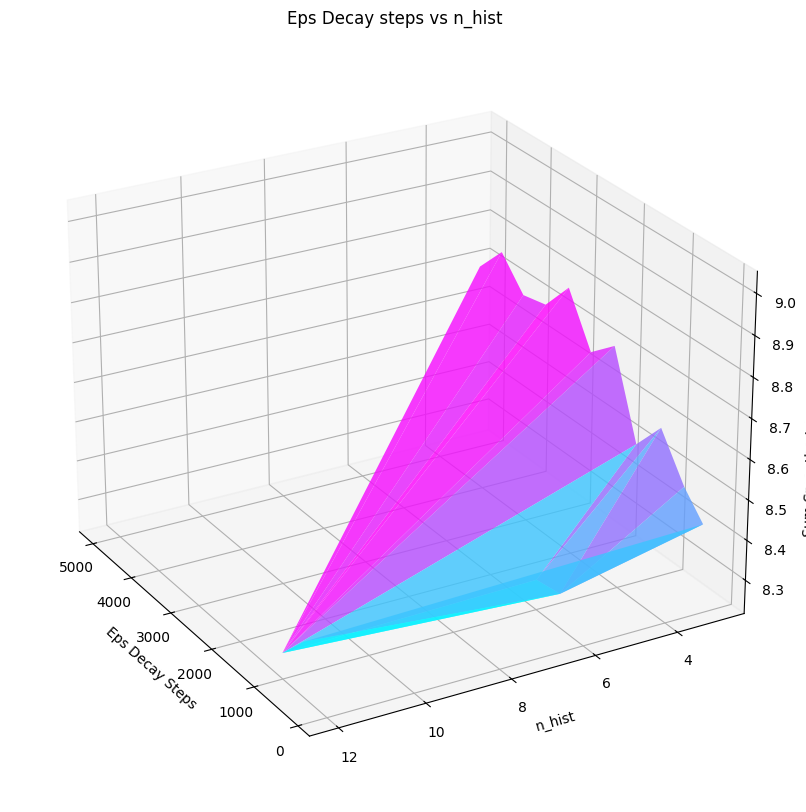

In [37]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(25, 150)

ax.plot_trisurf(results['self.eps_decay_steps'], results['self.n_hist'], results['log_sum'], cmap='cool', alpha=0.8)

ax.set_title('Eps Decay steps vs n_hist')
ax.set_xlabel('Eps Decay Steps')
ax.set_ylabel('n_hist')
ax.set_zlabel('Sum Smoothed Average')

plt.show()


### Plot Sum of Smoothed Average Against Gamma and n_hist

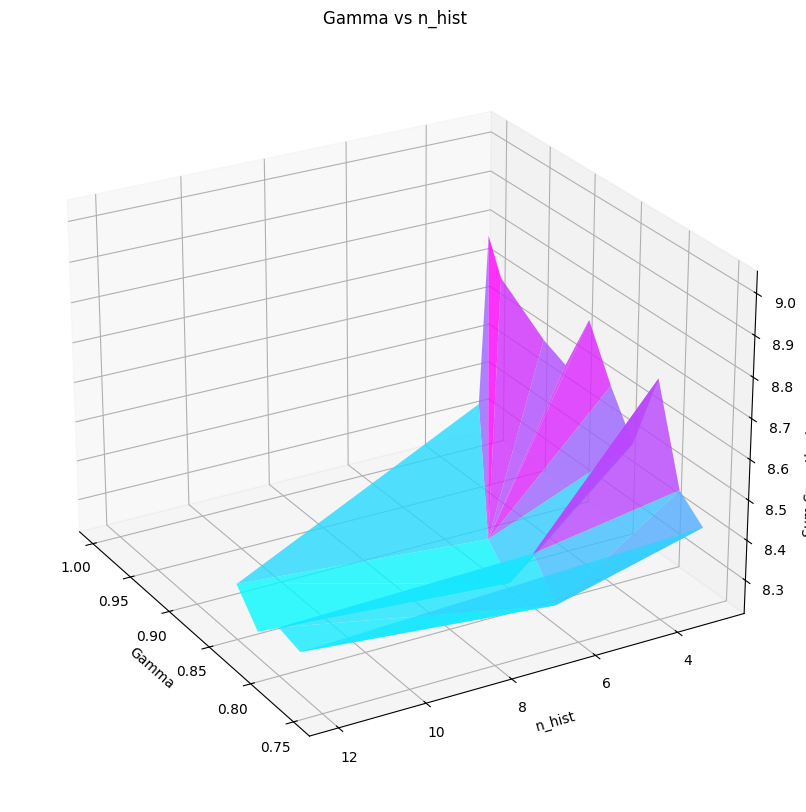

In [38]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(25, 150)

ax.plot_trisurf(results['self.gamma'], results['self.n_hist'], results['log_sum'], cmap='cool', alpha=0.8)

ax.set_title('Gamma vs n_hist')
ax.set_xlabel('Gamma')
ax.set_ylabel('n_hist')
ax.set_zlabel('Sum Smoothed Average')

plt.show()